In [1]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import MinMaxScaler

In [2]:
df = pd.read_csv('result.csv')

# Базова очистка
df = df.dropna()
df = df[(df['DTE'] > 0) & (df['C_IV'] > 0) & (df['C_LAST'] > 0)]
df['QUOTE_DATE'] = pd.to_datetime(df['QUOTE_DATE'])

# ! ВАЖЛИВО: Створюємо ідентифікатор групи (Expiry Date) ДО масштабування.
# Ми використовуємо реальні дні (DTE), щоб знайти дату експірації.
df['Expiry_Group'] = df['QUOTE_DATE'] + pd.to_timedelta(df['DTE'], unit='D')

# --- 2. Масштабування (Scaling) ---
feature_cols = ['UNDERLYING_LAST', 'STRIKE', 'DTE', 'C_IV']
target_col = ['C_LAST']

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

# Створюємо копію для масштабованих даних
df_scaled = df.copy()

# Масштабуємо тільки числові ознаки. 
# QUOTE_DATE та Expiry_Group залишаються в оригінальному форматі для коректного групування.
df_scaled[feature_cols] = scaler_X.fit_transform(df[feature_cols])
df_scaled[target_col] = scaler_y.fit_transform(df[target_col])

# --- 3. Функція створення послідовностей ---
def create_sequences(data, seq_length=5):
    X = []
    y = []
    
    # Групуємо за Страйком та Датою Експірації (яку ми розрахували раніше)
    groups = data.groupby(['STRIKE', 'Expiry_Group'])
    
    for name, group in groups:
        # Сортуємо за датою, щоб дні йшли по порядку
        group = group.sort_values('QUOTE_DATE')
        
        values_x = group[feature_cols].values
        values_y = group[target_col].values
        
        # Якщо в історії цього опціону менше записів, ніж довжина вікна - пропускаємо
        if len(values_x) < seq_length:
            continue
            
        # Створення ковзного вікна
        for i in range(len(values_x) - seq_length + 1):
            # Вхід: послідовність з N днів
            seq_x = values_x[i : i + seq_length]
            
            # Вихід: ціна на останній день цієї послідовності (поточна ціна)
            # Ми вчимо модель оцінювати ціну на основі патерну руху за останні 5 днів
            seq_y = values_y[i + seq_length - 1]
            
            X.append(seq_x)
            y.append(seq_y)
            
    return np.array(X), np.array(y)

# Генеруємо послідовності
SEQ_LENGTH = 5 
X, y = create_sequences(df_scaled, seq_length=SEQ_LENGTH)

print(f"Розмірність вхідних даних X: {X.shape}") # Очікуємо (Samples, 5, 4)
print(f"Розмірність вихідних даних y: {y.shape}") # Очікуємо (Samples, 1)

# --- 4. Розбиття на Train/Val/Test (Хронологічно) ---
# Оскільки ми вже згрупували та перемішали страйки, простий спліт спрацює коректно.
train_size = int(len(X) * 0.8)
val_size = int(len(X) * 0.1)

X_train, y_train = X[:train_size], y[:train_size]
X_val, y_val = X[train_size : train_size + val_size], y[train_size : train_size + val_size]
X_test, y_test = X[train_size + val_size:], y[train_size + val_size:]

print(f"Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

Розмірність вхідних даних X: (11265, 5, 4)
Розмірність вихідних даних y: (11265, 1)
Train: (9012, 5, 4), Val: (1126, 5, 4), Test: (1127, 5, 4)


In [3]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, BatchNormalization, Dropout
import matplotlib.pyplot as plt

# 1. Архітектура моделі (згідно зі слайдами 10-12)
def build_lstm_model(input_shape):
    model = Sequential()

    # --- Шар 1 ---
    # return_sequences=True передає послідовність на наступний шар
    model.add(LSTM(100, return_sequences=True, activation='relu', input_shape=input_shape))
    model.add(BatchNormalization()) 
    
    # --- Шар 2 ---
    model.add(LSTM(100, return_sequences=True, activation='relu'))
    model.add(BatchNormalization())

    # --- Шар 3 ---
    model.add(LSTM(100, return_sequences=True, activation='relu'))
    model.add(BatchNormalization())

    # --- Шар 4 ---
    # return_sequences=False, бо далі йде звичайний Dense шар
    model.add(LSTM(100, return_sequences=False, activation='relu'))
    model.add(BatchNormalization())

    # --- Вихідний шар ---
    # Один нейрон для прогнозу ціни
    model.add(Dense(1))

    # Компіляція: Оптимізатор Adam, функція втрат MSE (слайд 12)
    model.compile(optimizer='adam', loss='mse', metrics=['mae'])
    
    return model

In [4]:
input_shape = (X_train.shape[1], X_train.shape[2])
model = build_lstm_model(input_shape)

model.summary()

c:\Users\oopas\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 100)         │        42,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 5, 100)         │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 5, 100)         │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 5, 100)         │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 5, 100)         │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 5, 100)         │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ (None, 100)            │        80,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │           101 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 284,901 (1.09 MB)

 Trainable params: 284,101 (1.08 MB)

 Non-trainable params: 800 (3.12 KB)

In [5]:
print("\nПочинаємо навчання...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,           # Спробуємо 50 епох
    batch_size=32,
    verbose=1
)


Починаємо навчання...
Epoch 1/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - loss: 0.0550 - mae: 0.1430 - val_loss: 0.0033 - val_mae: 0.0433
Epoch 2/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0099 - mae: 0.0747 - val_loss: 0.0045 - val_mae: 0.0532
Epoch 3/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0068 - mae: 0.0626 - val_loss: 0.0133 - val_mae: 0.0830
Epoch 4/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0064 - mae: 0.0610 - val_loss: 0.0020 - val_mae: 0.0338
Epoch 5/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0057 - mae: 0.0575 - val_loss: 0.0066 - val_mae: 0.0574
Epoch 6/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.0054 - mae: 0.0557 - val_loss: 0.0088 - val_mae: 0.0671
Epoch 7/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0055 - mae: 0.0567 - val_loss: 0.0034 - val_mae: 0.0484
Epoch 8/50
282/282 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.0049 - mae: 0.0525 - val_loss: 0.0025 - val_mae: 0.0369
Epoch 9/50
282/282 ━━━━━━━━━━━━

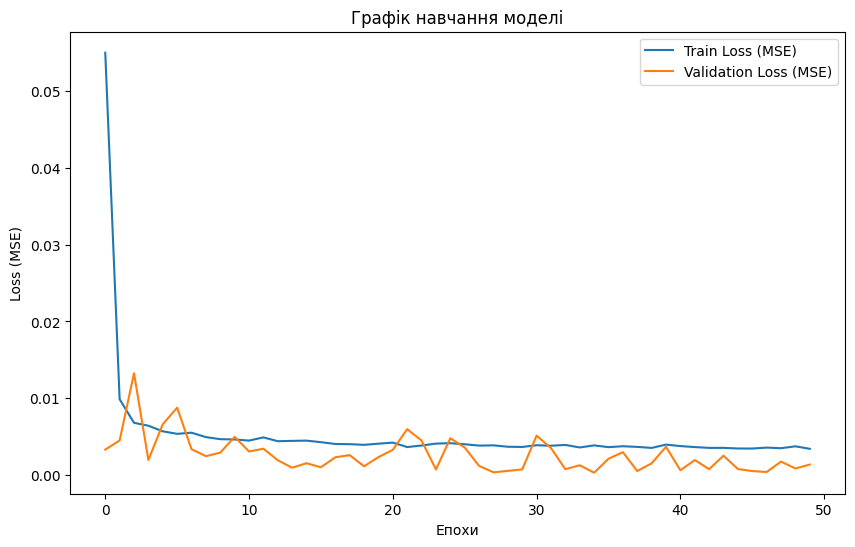

In [6]:
plt.figure(figsize=(10, 6))
plt.plot(history.history['loss'], label='Train Loss (MSE)')
plt.plot(history.history['val_loss'], label='Validation Loss (MSE)')
plt.title('Графік навчання моделі')
plt.xlabel('Епохи')
plt.ylabel('Loss (MSE)')
plt.legend()
plt.show()

In [7]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

predicted_stock_price = model.predict(X_test)

predicted_prices = scaler_y.inverse_transform(predicted_stock_price)
real_prices = scaler_y.inverse_transform(y_test.reshape(-1, 1))

mse = mean_squared_error(real_prices, predicted_prices)
mae = mean_absolute_error(real_prices, predicted_prices)

print(f"Середня абсолютна похибка (MAE): ${mae:.4f}")
print(f"Середньоквадратична похибка (MSE): {mse:.4f}")

36/36 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step
Середня абсолютна похибка (MAE): $5.6589
Середньоквадратична похибка (MSE): 51.0225


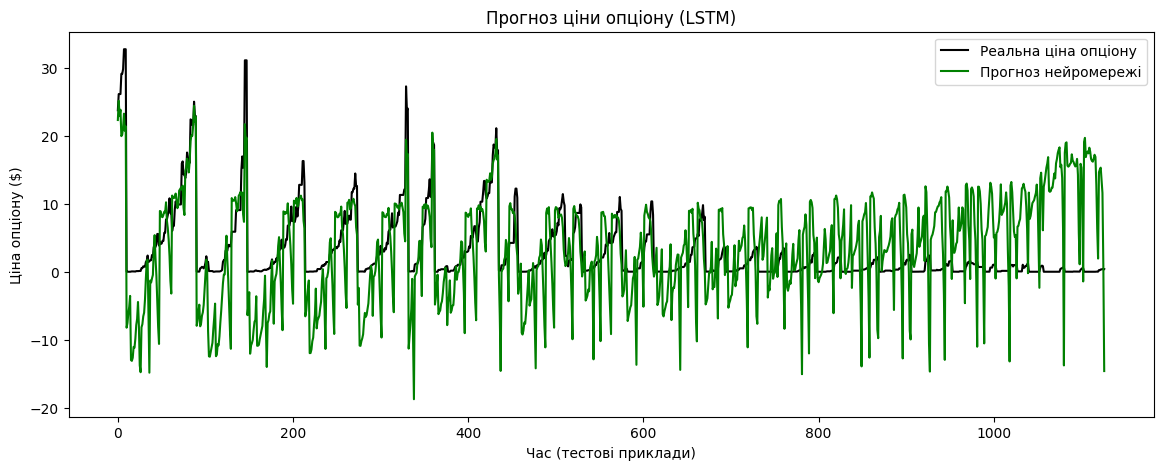

In [8]:
plt.figure(figsize=(14, 5))
plt.plot(real_prices, color='black', label='Реальна ціна опціону')
plt.plot(predicted_prices, color='green', label='Прогноз нейромережі')
plt.title('Прогноз ціни опціону (LSTM)')
plt.xlabel('Час (тестові приклади)')
plt.ylabel('Ціна опціону ($)')
plt.legend()
plt.show()

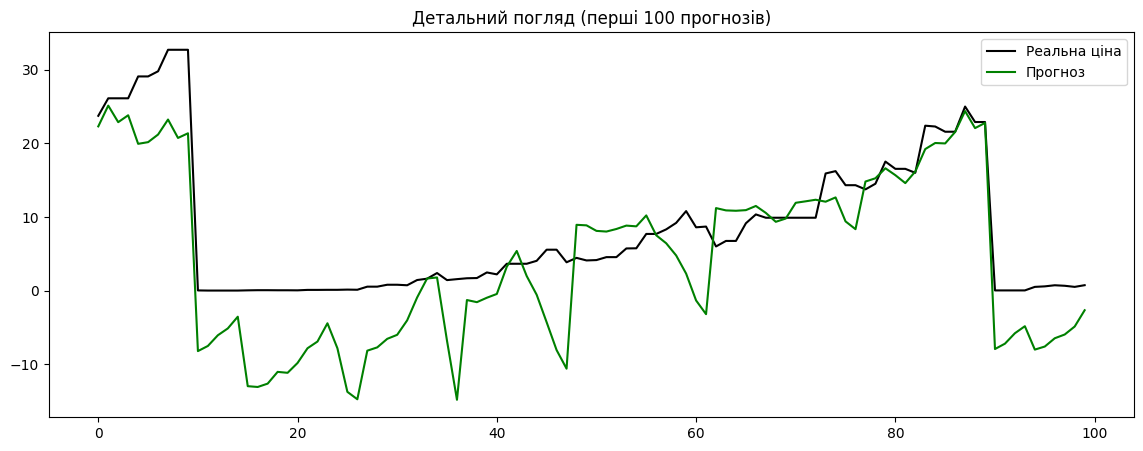

In [9]:
plt.figure(figsize=(14, 5))
plt.plot(real_prices[:100], color='black', label='Реальна ціна')
plt.plot(predicted_prices[:100], color='green', label='Прогноз')
plt.title('Детальний погляд (перші 100 прогнозів)')
plt.legend()
plt.show()

In [ ]:
import joblib
from tensorflow.keras.models import load_model

model_filename = 'lstm_option_pricing.keras'
model.save(model_filename)
print(f"Модель збережено у файл: {model_filename}")

scaler_x_filename = 'scaler_x.pkl'
scaler_y_filename = 'scaler_y.pkl'

joblib.dump(scaler_X, scaler_x_filename)
joblib.dump(scaler_y, scaler_y_filename)
print(f"Скейлери збережено: {scaler_x_filename}, {scaler_y_filename}")

print("\n--- Все готово для передачі або використання у майбутньому ---")

Модель збережено у файл: lstm_option_pricing.keras
Скейлери збережено: scaler_x.pkl, scaler_y.pkl

--- Все готово для передачі або використання у майбутньому ---
